# Backtest: long Q5 from D−12, short from D to D+5

**The rule, frozen from `insample.ipynb`.** For every forced short-covering deadline D, take the stocks whose margin
days-to-cover on D−17 is ≥ **0.167** (the in-sample 80th percentile) and whose 20-day turnover is ≥ NT$20m. **Buy at the
close of D−12**, **flip to short at the close of D**, **cover at the close of D+5**. Single-stock futures, unhedged, 20bp
per leg. Nothing below is re-fitted.

* **In-sample:** 2018-01-02 → 2023-10-25 (first 2/3 of trading days), the period the parameters were picked on.
* **Out-of-sample:** trades that *open* after 2023-10-25, through 2026-09-23. The threshold, liquidity filter, entry,
  exit and cost are all unchanged.
* **P&L, two sizing rules.** (1) **Fixed notional per trade (headline):** every trade gets the same notional, and
  daily P&L is the sum across open trades, in units of one trade's notional. That is how you would actually size it,
  and a day with 40 names open counts 40 times as much as a day with one. (2) **Average of open positions:** always
  fully invested, spread equally over whatever is open (the definition `insample.ipynb` used for the grid). This can
  put the whole book in one stock on a quiet day, and it underweights crowded days.
  Costs are charged on the day each leg closes.

## 1. Data, events, signal
**What this does.** Same construction as `insample.ipynb`: the TWSE panel, the ban calendar, and days-to-cover on D−17.
It applies the frozen threshold and liquidity filter to all events, then labels each trade in-sample or out-of-sample.

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})
DATA = Path("data")
K, H = 12, 5                 # long from the close of D-12 to D, short from the close of D to D+5
THR = 0.167                  # frozen: in-sample 80th pct of days-to-cover on D-17 (insample.ipynb)
SIG_LAG, MIN_VAL20, COST_LEG_BPS = 17, 2e7, 20
K_GRID, H_GRID = 15, 20      # the grid's widest trade, used for the in-sample boundary exactly as in insample.ipynb

is_stock = lambda s: s.str.fullmatch(r"[1-9]\d{3}")
px = pd.read_csv(DATA / "prices.csv", dtype={"stock_id": str}, parse_dates=["date"])
px = px[is_stock(px.stock_id)].drop_duplicates(["date", "stock_id"]).sort_values(["stock_id", "date"])
exd = pd.read_csv(DATA / "exdiv.csv", dtype={"stock_id": str}, parse_dates=["date"])
exd = exd.dropna(subset=["close_before", "ref_price"]).drop_duplicates(["date", "stock_id"])
exd["adj"] = exd.ref_price / exd.close_before
px = px.merge(exd[["date", "stock_id", "adj"]], on=["date", "stock_id"], how="left")
px["adj"] = px["adj"].fillna(1.0)
px["close_ff"] = px.groupby("stock_id")["close"].ffill()
px["ret"] = px.close / (px.groupby("stock_id")["close_ff"].shift() * px.adj) - 1
px.loc[px.ret.abs() > 0.105, "ret"] = np.nan

idx = pd.read_csv(DATA / "index.csv", parse_dates=["date"]).drop_duplicates("date").sort_values("date").set_index("date")
cal = idx.index
mg = pd.read_csv(DATA / "margin.csv", dtype={"stock_id": str}, parse_dates=["date"])
mg = mg[is_stock(mg.stock_id)].drop_duplicates(["date", "stock_id"])
stocks = pd.Index(sorted(set(px.stock_id) & set(mg.stock_id)))
wide = lambda df, c: df.pivot(index="date", columns="stock_id", values=c).reindex(index=cal, columns=stocks)
R = wide(px, "ret")
SB = wide(mg, "short_bal")
ADV = (wide(px, "volume") / 1000).rolling(20, min_periods=10).mean()
VAL20 = wide(px, "value").rolling(20, min_periods=10).mean()
col = {s: i for i, s in enumerate(stocks)}
T = len(cal); Rv = R.values
CUT = int(T * 2 / 3)
taiex = idx.taiex_tr.pct_change(fill_method=None).fillna(0).values

ev = pd.read_csv(DATA / "suspension.csv", dtype={"stock_id": str}, parse_dates=["date", "end_date"]).drop_duplicates()
ev = ev[ev.stock_id.isin(stocks)].copy()
ev["D"] = cal.searchsorted(ev.date.values)
ev = ev[(ev.D >= SIG_LAG + 1) & (ev.D + H + 1 < T)]
ev["j"] = ev.stock_id.map(col)
ev = ev.sort_values(["stock_id", "D"])
ev = ev[ev.groupby("stock_id").D.diff().fillna(99) >= 10].reset_index(drop=True)
s_ = ev.D.values - SIG_LAG
ev["dtc"] = SB.values[s_, ev.j.values] / ADV.values[s_, ev.j.values]
ev["val20"] = VAL20.values[s_, ev.j.values]
ev["Ddate"] = cal[ev.D.values]
ev["period"] = np.select([ev.D + H_GRID < CUT, ev.D - K >= CUT], ["in-sample", "out-of-sample"], "boundary")
tr = ev[(SB.values[s_, ev.j.values] > 0) & (ev.dtc >= THR) & (ev.val20 >= MIN_VAL20) & (ev.period != "boundary")].reset_index(drop=True)
print(f"in-sample {cal[0].date()} -> {cal[CUT - 1].date()} | out-of-sample {cal[CUT].date()} -> {cal[-1].date()}")
print(tr.groupby("period").agg(trades=("D", "size"), deadline_dates=("Ddate", "nunique"), stocks=("stock_id", "nunique"),
                                first=("Ddate", "min"), last=("Ddate", "max")).to_string())

in-sample 2018-01-02 -> 2023-10-25 | out-of-sample 2023-10-26 -> 2026-09-23
               trades  deadline_dates  stocks      first       last
period                                                             
in-sample        1059             361     396 2018-03-05 2023-09-21
out-of-sample     208             103     156 2023-11-14 2026-09-02


## 2. Run the backtest
**What this does.** Each trade holds +1 on days D−11…D and −1 on days D+1…D+5. Costs: 20bp on D (the long closes) and
20bp on D+5 (the short closes). It builds the daily portfolio return (the average across open positions) for the
combined trade and for each leg separately, and one net return per trade.

In [2]:
OFF = np.arange(-K + 1, H + 1)
SIGN = np.where(OFF <= 0, 1.0, -1.0)
Dv, Jv = tr.D.values, tr.j.values
DAYS = Dv[:, None] + OFF[None, :]
RET = np.nan_to_num(Rv[DAYS, Jv[:, None]])
cost = COST_LEG_BPS / 1e4

def daily_pnl(leg_mask, charge):
    pnl = SIGN[None, :] * RET
    pnl = np.where(leg_mask[None, :], pnl, 0.0)
    for o in charge:
        pnl[:, OFF == o] -= cost
    open_ = np.broadcast_to(leg_mask, pnl.shape)
    s = np.zeros(T); c = np.zeros(T)
    np.add.at(s, DAYS[open_], pnl[open_]); np.add.at(c, DAYS[open_], 1)
    return pd.Series(np.divide(s, c, out=np.zeros(T), where=c > 0), cal), pd.Series(c, cal), pnl.sum(1)

full, npos, trade_ret = daily_pnl(np.ones(len(OFF), bool), [0, H])
long_leg, _, long_tr = daily_pnl(OFF <= 0, [0])
short_leg, _, short_tr = daily_pnl(OFF >= 1, [H])
tr["net"], tr["long_net"], tr["short_net"] = trade_ret, long_tr, short_tr
is_day = pd.Series(np.arange(T) < CUT, cal)

def fixed_notional(leg_mask, charge):
    pnl = np.where(leg_mask[None, :], SIGN[None, :] * RET, 0.0)
    for o in charge:
        pnl[:, OFF == o] -= cost
    s = np.zeros(T); np.add.at(s, DAYS.ravel(), pnl.ravel())
    return pd.Series(s, cal)
fx_full = fixed_notional(np.ones(len(OFF), bool), [0, H])
fx_long = fixed_notional(OFF <= 0, [0])
fx_short = fixed_notional(OFF >= 1, [H])
print(f"days with an open position: {(npos > 0).sum()} of {T} ({(npos > 0).mean():.0%}); median positions when open: {npos[npos > 0].median():.0f}")

days with an open position: 1747 of 2122 (82%); median positions when open: 4


## 3. P&L: in-sample and out-of-sample together
**What this does.** Cumulative P&L of the combined trade (and each leg), with the in-sample period shaded. For scale,
a TAIEX buy-and-hold line shows what just being long the market did over the same days (the strategy is unhedged).

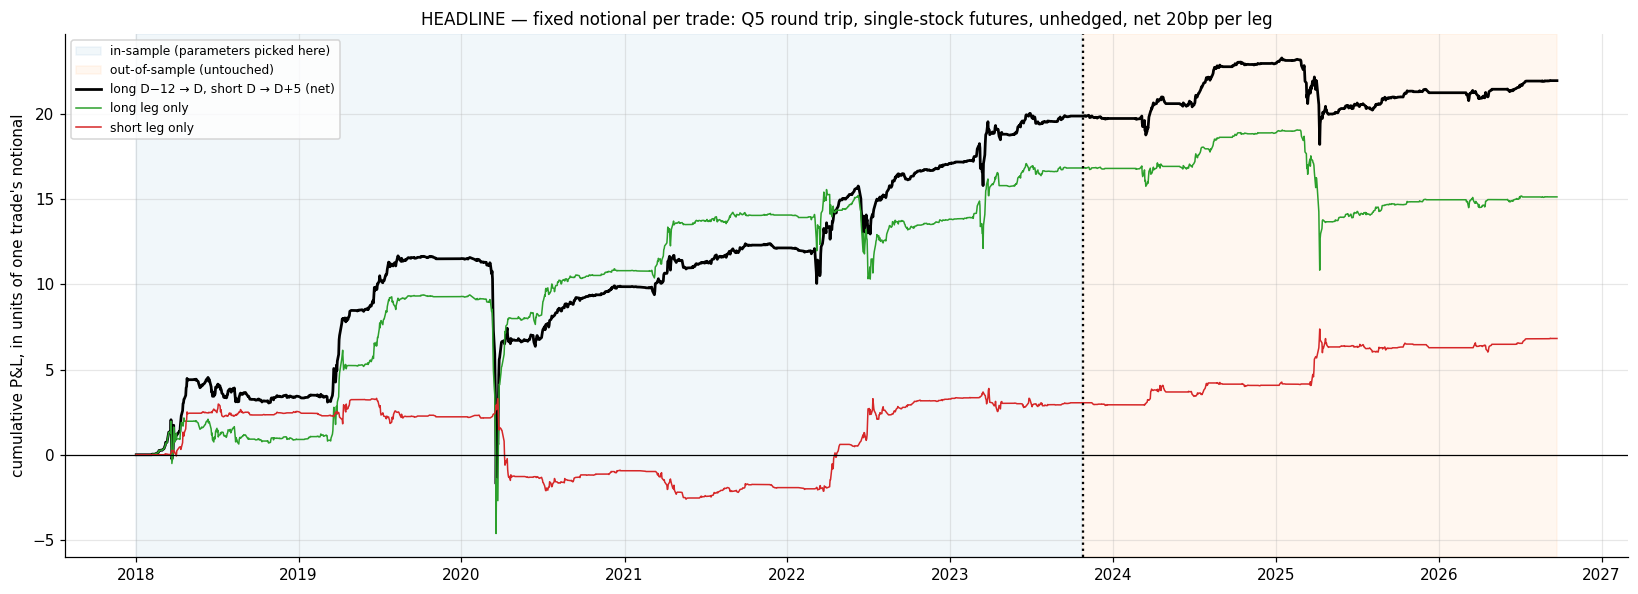

In [3]:
fig, ax = plt.subplots(figsize=(15, 5.5))
ax.axvspan(cal[0], cal[CUT - 1], color="C0", alpha=.06, label="in-sample (parameters picked here)")
ax.axvspan(cal[CUT], cal[-1], color="C1", alpha=.06, label="out-of-sample (untouched)")
ax.plot(cal, fx_full.cumsum(), color="k", lw=1.8, label=f"long D−{K} → D, short D → D+{H} (net)")
ax.plot(cal, fx_long.cumsum(), color="C2", lw=1, label="long leg only")
ax.plot(cal, fx_short.cumsum(), color="C3", lw=1, label="short leg only")
ax.axvline(cal[CUT], color="k", ls=":"); ax.axhline(0, color="k", lw=.8)
ax.set_ylabel("cumulative P&L, in units of one trade's notional")
ax.set_title(f"HEADLINE — fixed notional per trade: Q5 round trip, single-stock futures, unhedged, net {COST_LEG_BPS}bp per leg", fontsize=11)
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

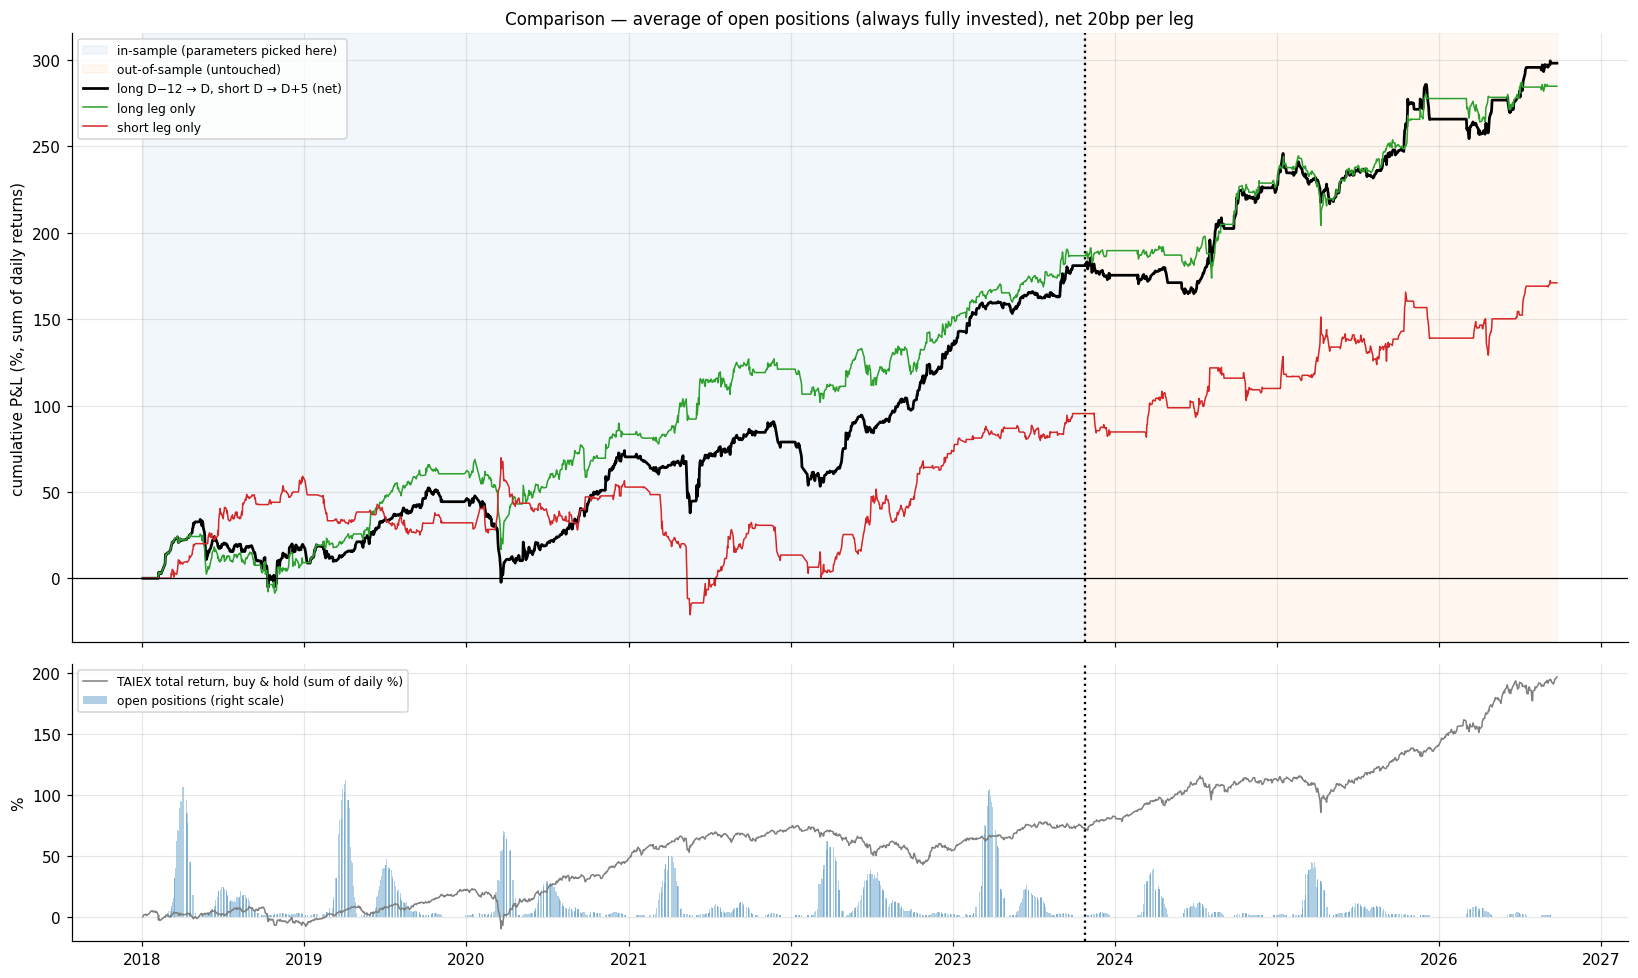

In [4]:
fig, ax = plt.subplots(2, 1, figsize=(15, 9), gridspec_kw={"height_ratios": [2.2, 1]}, sharex=True)
a = ax[0]
a.axvspan(cal[0], cal[CUT - 1], color="C0", alpha=.06, label="in-sample (parameters picked here)")
a.axvspan(cal[CUT], cal[-1], color="C1", alpha=.06, label="out-of-sample (untouched)")
a.plot(cal, full.cumsum() * 100, color="k", lw=1.8, label=f"long D−{K} → D, short D → D+{H} (net)")
a.plot(cal, long_leg.cumsum() * 100, color="C2", lw=1, label="long leg only")
a.plot(cal, short_leg.cumsum() * 100, color="C3", lw=1, label="short leg only")
a.axvline(cal[CUT], color="k", ls=":")
a.axhline(0, color="k", lw=.8)
a.set_ylabel("cumulative P&L (%, sum of daily returns)")
a.set_title(f"Comparison — average of open positions (always fully invested), net {COST_LEG_BPS}bp per leg", fontsize=11)
a.legend(fontsize=8, loc="upper left")
b = ax[1]
b.plot(cal, np.cumsum(taiex) * 100, color="C7", lw=1, label="TAIEX total return, buy & hold (sum of daily %)")
b.bar(cal, npos, color="C0", alpha=.35, width=1.5, label="open positions (right scale)")
b.axvline(cal[CUT], color="k", ls=":"); b.legend(fontsize=8, loc="upper left"); b.set_ylabel("%")
plt.tight_layout(); plt.show()

## 4. Statistics
**What this does.** For each period: Sharpe (daily series, √252), annualised return and volatility, max drawdown, number
of trades and deadline dates, mean net return per trade, hit rate, t-stat across deadline dates, and each leg's
contribution. Then the same by calendar year, and the correlation of daily strategy P&L with TAIEX.

In [5]:
def stats(daily, trades, dates):
    d = daily
    eq = d.cumsum()
    per_date = pd.Series(trades).groupby(dates).mean()
    return {"Sharpe": d.mean() / d.std() * np.sqrt(252), "ann. return %": d.mean() * 252 * 100, "ann. vol %": d.std() * np.sqrt(252) * 100,
            "max drawdown %": (eq - eq.cummax()).min() * 100, "trades": len(trades), "deadline dates": len(per_date),
            "mean net / trade bp": np.mean(trades) * 1e4, "hit rate": np.mean(np.asarray(trades) > 0),
            "t (per date)": per_date.mean() / per_date.std() * np.sqrt(len(per_date))}

rows = {}
for per, dm in [("in-sample", is_day.values), ("out-of-sample", ~is_day.values), ("full", np.ones(T, bool))]:
    tm = (tr.period == per).values if per != "full" else np.ones(len(tr), bool)
    rows[per] = stats(full[dm], tr.net.values[tm], tr.Ddate.values[tm])
    fx = fx_full[dm]; eqx = fx.cumsum()
    rows[per] = {"FIXED-NOTIONAL Sharpe": fx.mean() / fx.std() * np.sqrt(252), "fixed-notional total P&L (trade units)": fx.sum(),
                 "fixed-notional max drawdown (trade units)": (eqx - eqx.cummax()).min(),
                 "fixed-notional long-leg Sharpe": fx_long[dm].mean() / fx_long[dm].std() * np.sqrt(252),
                 "fixed-notional short-leg Sharpe": fx_short[dm].mean() / fx_short[dm].std() * np.sqrt(252),
                 **{("avg-of-open " + k if k in ["Sharpe", "ann. return %", "ann. vol %", "max drawdown %"] else k): v for k, v in rows[per].items()}}
    rows[per]["long leg / trade bp"] = tr.long_net.values[tm].mean() * 1e4
    rows[per]["short leg / trade bp"] = tr.short_net.values[tm].mean() * 1e4
    rows[per]["avg-of-open long-leg Sharpe"] = long_leg[dm].mean() / long_leg[dm].std() * np.sqrt(252)
    rows[per]["avg-of-open short-leg Sharpe"] = short_leg[dm].mean() / short_leg[dm].std() * np.sqrt(252)
    rows[per]["corr with TAIEX (daily, open days)"] = np.corrcoef(full[dm][npos[dm] > 0], taiex[dm][npos[dm].values > 0])[0, 1]
print(pd.DataFrame(rows).round(3).to_string())

yr = []
for y, g in tr.groupby(tr.Ddate.dt.year):
    dm = (cal.year == y)
    yr.append({"year": y, "trades": len(g), "mean net bp": g.net.mean() * 1e4, "long bp": g.long_net.mean() * 1e4,
               "short bp": g.short_net.mean() * 1e4, "hit": (g.net > 0).mean(),
               "fixed-notional Sharpe": fx_full[dm].mean() / fx_full[dm].std() * np.sqrt(252),
               "avg-of-open Sharpe": full[dm].mean() / full[dm].std() * np.sqrt(252), "TAIEX %": taiex[dm].sum() * 100,
               "period": "/".join(sorted(g.period.unique()))})
print("\n" + pd.DataFrame(yr).set_index("year").round(2).to_string())
worst = tr.groupby("Ddate").agg(trades=("net", "size"), long_bp=("long_net", "mean"), short_bp=("short_net", "mean"), net_bp=("net", "mean"))
worst[["long_bp", "short_bp", "net_bp"]] *= 1e4
worst["net_trade_units"] = worst.net_bp / 1e4 * worst.trades
print("\nworst 8 deadline dates by total P&L (fixed notional):")
print(worst.sort_values("net_trade_units").head(8).round(1).to_string())

                                           in-sample  out-of-sample      full
FIXED-NOTIONAL Sharpe                          0.881          0.340     0.742
fixed-notional total P&L (trade units)        19.876          2.078    21.954
fixed-notional max drawdown (trade units)    -13.384         -5.076   -13.384
fixed-notional long-leg Sharpe                 0.642         -0.221     0.435
fixed-notional short-leg Sharpe                0.321          1.080     0.521
avg-of-open Sharpe                             1.231          1.405     1.292
avg-of-open ann. return %                     32.258         41.719    35.415
avg-of-open ann. vol %                        26.194         29.686    27.403
avg-of-open max drawdown %                   -54.639        -31.348   -54.639
trades                                      1059.000        208.000  1267.000
deadline dates                               361.000        103.000   464.000
mean net / trade bp                          187.682         99.

**Interpretation.**
- **Headline (fixed notional per trade): Sharpe 0.88 in-sample, 0.34 out-of-sample.** P&L per trade holds up
  (+188bp → +100bp net, 59% → 51% hit), but out-of-sample the t-stat across deadline dates is only 1.9, and nearly all the
  gain is 2024 (Sharpe 2.2). 2025 lost money (−162bp per trade).
- **Sizing changes the answer.** The "average of open positions" series scores 1.23 / 1.41, because it counts a crowded
  day with 12 positions no more than a quiet day with one. The crowded days are exactly where the risk is. That is why
  fixed notional is the headline and the grid's 1.23 overstates what the trade delivers.
- **The long leg carries the crashes.** The worst deadline dates are March 2020 (COVID: 12 trades averaging −30% on the
  long leg into 2020-03-20) and April 2025 (tariff crash: 8 trades at −19% into 2025-04-11, 5 more into 04-14). Deadlines
  cluster in March–April (AGM bans), so one market shock hits a dozen long positions at once. Out-of-sample the long leg
  loses −82bp per trade, and its fixed-notional Sharpe is −0.22.
- **The short leg is what held up out-of-sample.** +29bp per trade in-sample, then **+181bp per trade and Sharpe 1.08
  out-of-sample**. That matches `drop.ipynb`, where the post-deadline fall was the cleaner effect.
- **Fewer trades out-of-sample** (79, 106 and 18 a year vs ~180 in-sample). With the fixed days-to-cover threshold, fewer
  names qualify, because turnover rose sharply in 2024–26 and each stock's short book is now fewer days of volume.
- **Takeaways:** (i) the unhedged 12-day long is mostly market exposure and needs a hedge or a much shorter holding
  period. (ii) The short-after-deadline leg is the part that generalises. (iii) The next grid should be run with
  fixed-notional Sharpe, and should look at the legs separately.